# 27 — LSTM and GRU Intuition

Vanilla RNNs repeatedly replace one hidden state with another. LSTMs and GRUs introduce learned gates that control what is preserved, written, exposed, or reset. This notebook emphasizes those information paths before larger sequence applications.

## Learning objectives

- distinguish an LSTM hidden state from its cell state;
- derive the dimensions of all LSTM gates;
- implement and numerically check one LSTM step;
- explain the direct cell-state gradient path;
- run an LSTM over a complete sequence;
- compare the structures of vanilla RNNs, LSTMs, and GRUs;
- implement one GRU forward step.


## Numerically stable sigmoid helper

The usual sigmoid formula is $\sigma(x)=1/(1+e^{-x})$. For a very negative $x$, however, calculating $e^{-x}$ can overflow. An algebraically equivalent formula is

$$
\sigma(x)=\frac{e^x}{1+e^x}.
$$

The helper below uses the first formula for $x\geq0$ and the second for $x<0$. In both branches the exponent passed to the exponential is nonpositive, avoiding unnecessarily large intermediate values. Both branches still compute the same sigmoid function.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import eval_numerical_gradient_array, relative_error

SEED = 42
generator = np.random.default_rng(SEED)


def sigmoid(x):
    """Compute sigmoid with separate stable formulas by sign."""
    output = np.empty_like(x, dtype=np.result_type(x, np.float32))
    positive = x >= 0
    output[positive] = 1.0 / (1.0 + np.exp(-x[positive]))
    exp_x = np.exp(x[~positive])
    output[~positive] = exp_x / (1.0 + exp_x)
    return output


## 1. LSTM state and gate shapes

At each step an LSTM carries two arrays, both with shape $(N,H)$:

- hidden state $h_t$: the exposed representation used by outputs and the next step;
- cell state $c_t$: an internal memory path controlled by gates.

One affine calculation produces four groups of $H$ values:

$$
A=x_tW_x+h_{t-1}W_h+b, \qquad A\in\mathbb{R}^{N\times4H}.
$$

The two state arrays do not directly turn into four blocks. Instead, each weight matrix stores four different projections side by side. Conceptually,

$$
W_x=[W_{xi}\;W_{xf}\;W_{xo}\;W_{xg}],
$$

where every smaller matrix has shape $(D,H)$. Their horizontal concatenation therefore has shape $(D,4H)$. Similarly,

$$
W_h=[W_{hi}\;W_{hf}\;W_{ho}\;W_{hg}]
$$

has shape $(H,4H)$, and the bias concatenates four vectors of length $H$. The packed matrix operations have these shapes:

- $x_t\;(N,D)\;W_x\;(D,4H)\rightarrow(N,4H)$;
- $h_{t-1}\;(N,H)\;W_h\;(H,4H)\rightarrow(N,4H)$;
- adding both products and the $(4H,)$ bias leaves one $(N,4H)$ array.

For example, with $N=2$, $D=3$, and $H=5$, both matrix products have shape $(2,20)$. Adding them does not double the width: corresponding entries are added, leaving one $(2,20)$ array. Splitting its 20 columns into four consecutive groups produces four arrays of shape $(2,5)$.

This packed calculation is equivalent to performing four separate affine transformations—one for each gate—but is more compact and efficient. The column order is a convention; this notebook consistently uses input, forget, output, candidate.

We split $A$ into input, forget, output, and candidate blocks:

$$
i=\sigma(A_i),\quad f=\sigma(A_f),\quad o=\sigma(A_o),\quad g=\tanh(A_g).
$$

The three sigmoid gates contain values between zero and one. The candidate $g$ contains proposed content between minus one and one. The previous cell state $c_{t-1}$ does not participate in this gate-producing affine calculation; it enters immediately afterward in the cell-state update introduced in Section 2.

### Exercise 1 — Complete the parameter shapes


In [6]:
N, D, H = 2, 3, 5

# replace None with explicit shape tuples.
weights_x_shape = (D, 4 * H)
weights_h_shape = (H, 4 * H)
bias_shape = (4 * H,)
affine_output_shape = (N, 4 * H)
one_gate_shape = (N, H)

assert weights_x_shape == (D, 4 * H)
assert weights_h_shape == (H, 4 * H)
assert bias_shape == (4 * H,)
assert affine_output_shape == (N, 4 * H)
assert one_gate_shape == (N, H)


## 2. One LSTM forward step

The cell update first preserves part of the previous memory and writes part of the candidate:

$$
c_t=f\odot c_{t-1}+i\odot g.
$$

The output gate controls how much of the squashed cell is exposed:

$$
h_t=o\odot\tanh(c_t).
$$

These equations give the gates different roles:

- $f$: how much old cell memory to preserve;
- $i$: how much candidate content to write;
- $o$: how much cell information to expose as hidden state;
- $g$: proposed new cell content.

### Exercise 2 — Implement one LSTM step

Calculate the combined affine output, split it into four equal blocks along the feature axis, apply the activations, and update both states.


In [ ]:
def lstm_step_forward(x_t, h_previous, c_previous, weights_x, weights_h, bias):
    """Compute one LSTM time step using gate order i, f, o, g."""
    # implement the gate and state equations.

    # Produce all four gate pre-activations at once.
    activation = x_t @ weights_x + h_previous @ weights_h + bias

    # Each pre-activation block has shape (N, H).
    activation_i, activation_f, activation_o, activation_g = np.split(
        activation, 4, axis=1,
    )

    # Convert pre-activations into gates and candidate content.
    i = sigmoid(activation_i)
    f = sigmoid(activation_f)
    o = sigmoid(activation_o)
    g = np.tanh(activation_g)

    # Update the internal memory.
    c_next = f * c_previous + i * g

    # Expose part of that memory as the hidden state.
    h_next = o * np.tanh(c_next)

    cache = (
        x_t, h_previous, c_previous, weights_x,  weights_h, i,  f, o, g, c_next,
    )

    return h_next, c_next, cache


step_x = generator.normal(size=(2, 3))
step_h_previous = generator.normal(size=(2, 4))
step_c_previous = generator.normal(size=(2, 4))
step_weights_x = generator.normal(scale=0.2, size=(3, 16))
step_weights_h = generator.normal(scale=0.2, size=(4, 16))
step_bias = generator.normal(scale=0.1, size=16)
step_h, step_c, step_cache = lstm_step_forward(
    step_x, step_h_previous, step_c_previous,
    step_weights_x, step_weights_h, step_bias,
)
assert step_h.shape == step_h_previous.shape
assert step_c.shape == step_c_previous.shape
assert len(step_cache) == 10


## 3. A controlled memory experiment

If the input gate is almost zero and the candidate is zero, the update is approximately $c_t=f\odot c_{t-1}$. The forget gate then determines how quickly existing memory decays.

The following experiment fixes all weights at zero and changes only the forget-gate bias. This isolates one gate; trained LSTMs normally use all gates together.


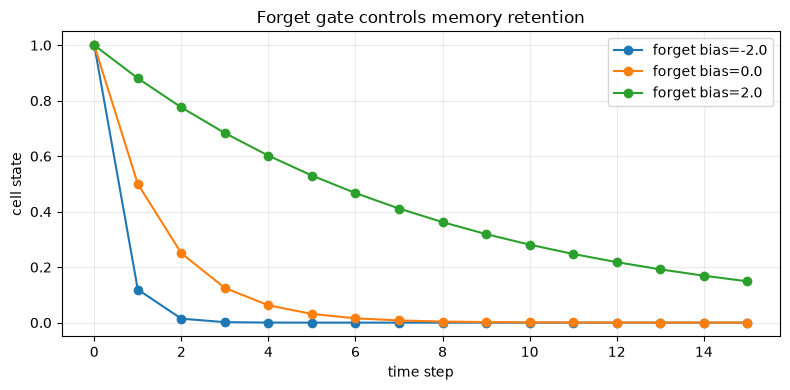

In [ ]:
num_steps = 15
memory_curves = {}
for forget_bias in (-2.0, 0.0, 2.0):
    x_t = np.zeros((1, 1))
    h_t = np.zeros((1, 1))
    c_t = np.ones((1, 1))
    weights_x = np.zeros((1, 4))
    weights_h = np.zeros((1, 4))
    # Gate order is i, f, o, g. Close input, vary forget, open output.
    bias = np.array([-8.0, forget_bias, 8.0, 0.0])
    values = [float(c_t[0, 0])]
    for _ in range(num_steps):
        h_t, c_t, _ = lstm_step_forward(
            x_t, h_t, c_t, weights_x, weights_h, bias
        )
        values.append(float(c_t[0, 0]))
    memory_curves[forget_bias] = values

fig, ax = plt.subplots(figsize=(8, 4))
for forget_bias, values in memory_curves.items():
    ax.plot(values, marker="o", label=f"forget bias={forget_bias}")
ax.set_xlabel("time step")
ax.set_ylabel("cell state")
ax.set_title("Forget gate controls memory retention")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# TODO: briefly explain why the three curves decay at different rates.
# With the input gate nearly closed and the candidate equal to zero, the update is approximately $c_t=f c_{t-1}$.
# A negative forget bias produces a gate close to zero and fast decay;
# zero bias produces $f=0.5$; and a positive bias produces a gate closer to one, so memory decays more slowly.

## 4. Backward through one LSTM step

Two upstream gradients enter a step: $dh_t$ through the exposed hidden state and $dc_t$ through the cell-state path. First backpropagate through $h_t=o\odot\tanh(c_t)$:

$$
do=dh_t\odot\tanh(c_t),
$$

$$
dc_{total}=dc_t+dh_t\odot o\odot(1-\tanh^2(c_t)).
$$

Then backpropagate through $c_t=f\odot c_{t-1}+i\odot g$:

$$
dc_{t-1}=dc_{total}\odot f,\quad df=dc_{total}\odot c_{t-1},
$$

$$
di=dc_{total}\odot g,\quad dg=dc_{total}\odot i.
$$

Finally apply the sigmoid derivative $q(1-q)$ to $i,f,o$ and the tanh derivative $1-g^2$ to $g$. Concatenate the four pre-activation gradients in the original i, f, o, g order. The remaining affine derivatives have the same structure as the vanilla RNN.

The important cell-state path is $dc_{t-1}=dc_{total}\odot f$: its local multiplier is the learned forget gate rather than another full recurrent matrix multiplication.

### Exercise 3 — Implement one-step LSTM backward


In [9]:
def lstm_step_backward(dh_next, dc_next, cache):
    """Backpropagate through one LSTM time step."""
    # unpack the cache and implement the equations above.
    (
        x_t,
        h_previous,
        c_previous,
        weights_x,
        weights_h,
        i,
        f,
        o,
        g,
        c_next,
    ) = cache

    # h_next = o * tanh(c_next)
    tanh_c_next = np.tanh(c_next)

    # Gradient entering the output gate.
    doutput_gate = dh_next * tanh_c_next

    # c_next receives one gradient directly through dc_next and another
    # through h_next = o * tanh(c_next).
    dc_total = (
        dc_next
        + dh_next * o * (1.0 - tanh_c_next**2)
    )

    # c_next = f * c_previous + i * g
    dc_previous = dc_total * f
    dforget_gate = dc_total * c_previous
    dinput_gate = dc_total * g
    dcandidate = dc_total * i

    # Backpropagate through the three sigmoid gates.
    dactivation_i = dinput_gate * i * (1.0 - i)
    dactivation_f = dforget_gate * f * (1.0 - f)
    dactivation_o = doutput_gate * o * (1.0 - o)

    # The candidate uses tanh rather than sigmoid.
    dactivation_g = dcandidate * (1.0 - g**2)

    # Reconstruct the gradient of the packed (N, 4H) affine output.
    dactivation = np.concatenate(
        (
            dactivation_i,
            dactivation_f,
            dactivation_o,
            dactivation_g,
        ),
        axis=1,
    )

    # Backpropagate through:
    # activation = x_t @ weights_x + h_previous @ weights_h + bias
    dx_t = dactivation @ weights_x.T
    dh_previous = dactivation @ weights_h.T
    dweights_x = x_t.T @ dactivation
    dweights_h = h_previous.T @ dactivation
    dbias = np.sum(dactivation, axis=0)

    return (
        dx_t,
        dh_previous,
        dc_previous,
        dweights_x,
        dweights_h,
        dbias,
    )


step_dh = generator.normal(size=step_h.shape)
step_dc = generator.normal(size=step_c.shape)
step_gradients = lstm_step_backward(step_dh, step_dc, step_cache)
expected_shapes = (
    step_x.shape, step_h_previous.shape, step_c_previous.shape,
    step_weights_x.shape, step_weights_h.shape, step_bias.shape,
)
for gradient, expected_shape in zip(step_gradients, expected_shapes):
    assert gradient.shape == expected_shape


## 5. Numerical check of the LSTM step

The step has two outputs, hidden state and cell state. For numerical checking, concatenate them along the feature axis and concatenate their upstream gradients in the same order.

### Exercise 4 — Check all one-step gradients


In [10]:
def combined_lstm_output(x_t, h_previous, c_previous, weights_x, weights_h, bias):
    h_next, c_next, _ = lstm_step_forward(
        x_t, h_previous, c_previous, weights_x, weights_h, bias
    )
    return np.concatenate((h_next, c_next), axis=1)


combined_upstream = np.concatenate((step_dh, step_dc), axis=1)
analytical = lstm_step_backward(step_dh, step_dc, step_cache)
arguments = [
    step_x, step_h_previous, step_c_previous,
    step_weights_x, step_weights_h, step_bias,
]
gradient_names = ("dx", "dh_previous", "dc_previous", "dW_x", "dW_h", "db")
for index, (name, value, analytical_gradient) in enumerate(
    zip(gradient_names, arguments, analytical)
):
    def forward(candidate):
        current = arguments.copy()
        current[index] = candidate
        return combined_lstm_output(*current)

    numerical_gradient = eval_numerical_gradient_array(
        forward, value, combined_upstream
    )
    error = relative_error(analytical_gradient, numerical_gradient)
    print(f"{name:12s}: {error:.3e}")
    assert error < 1e-8


dx          : 2.977e-11
dh_previous : 9.504e-11
dc_previous : 4.635e-12
dW_x        : 3.442e-09
dW_h        : 2.186e-10
db          : 2.244e-10


## 6. LSTM sequence forward pass

Sequence unrolling is similar to a vanilla RNN, except both $h_t$ and $c_t$ are carried forward. We initialize $c_0$ to zero here and expose all hidden states. A later model could also retain the cell states when needed.

### Exercise 5 — Unroll the LSTM


In [16]:
def lstm_forward(x, h0, weights_x, weights_h, bias):
    """Run an LSTM over x with shape (N, T, D)."""
    # carry both h_previous and c_previous through time.

    # init shapes and states
    N, T, _ = x.shape
    hidden_dim = h0.shape[1]
    h_previous = h0
    c_previous = np.zeros_like(h0)

    # init states and cache history
    hidden_states = np.empty(
        (N, T, hidden_dim),
        dtype=np.result_type(x, h0, weights_x, weights_h, bias),
    )
    cell_states = np.empty(
        (N, T, hidden_dim),
        dtype=np.result_type(x, h0, weights_x, weights_h, bias),
    )
    caches = []

    for t in range(T):
        # cacluate current step values
        h_t, c_t, cache = lstm_step_forward(
            x[:, t, :], h_previous, c_previous, weights_x, weights_h, bias
        )
        # save current step values
        hidden_states[:, t, :] = h_t
        cell_states[:, t, :] = c_t
        caches.append(cache)
        # set current states as previous for next iteration
        c_previous = c_t
        h_previous = h_t

    return hidden_states, cell_states, caches


sequence_x = generator.normal(size=(2, 5, 3))
sequence_h0 = generator.normal(size=(2, 4))
sequence_weights_x = generator.normal(scale=0.2, size=(3, 16))
sequence_weights_h = generator.normal(scale=0.2, size=(4, 16))
sequence_bias = generator.normal(scale=0.1, size=16)
sequence_hidden, sequence_cells, sequence_caches = lstm_forward(
    sequence_x, sequence_h0, sequence_weights_x,
    sequence_weights_h, sequence_bias,
)
assert sequence_hidden.shape == (2, 5, 4)
assert sequence_cells.shape == (2, 5, 4)
assert len(sequence_caches) == 5


## 7. GRU: a related gated recurrent unit

A GRU keeps one hidden state rather than separate hidden and cell states. One common convention is

$$
z=\sigma(x_tW_{xz}+h_{t-1}W_{hz}+b_z),
$$

$$
r=\sigma(x_tW_{xr}+h_{t-1}W_{hr}+b_r),
$$

$$
g=\tanh(x_tW_{xg}+(r\odot h_{t-1})W_{hg}+b_g),
$$

$$
h_t=(1-z)\odot h_{t-1}+z\odot g.
$$

The reset gate $r$ controls how much previous state is used to build the candidate. The update gate $z$ interpolates between the old state and the candidate. Some sources swap the roles of $z$ and $1-z$ in the final equation; the implementation and explanation must use one convention consistently.

### Exercise 6 — Implement one GRU forward step


In [18]:
def gru_step_forward(
    x_t, h_previous,
    weights_x_gates, weights_h_gates, bias_gates,
    weights_x_candidate, weights_h_candidate, bias_candidate,
):
    """Compute one GRU step using combined z and r gate parameters."""
    # calculate z and r, then candidate g and h_next.
    activation = x_t @ weights_x_gates + h_previous @ weights_h_gates + bias_gates
    activation_z, activation_r = np.split(
        activation, 2, axis=1
    )

    z = sigmoid(activation_z)
    r = sigmoid(activation_r)

    activation_g = x_t @ weights_x_candidate + (r * h_previous) @ weights_h_candidate + bias_candidate
    g = np.tanh(activation_g)

    h_t = (1 - z) * h_previous + z * g

    # Retain inputs and weights for gradient propagation, plus the activated
    # gates needed for their local sigmoid and tanh derivatives. Bias values
    # are unnecessary because bias gradients sum pre-activation gradients.
    cache = (
        x_t,
        h_previous,
        weights_x_gates,
        weights_h_gates,
        weights_x_candidate,
        weights_h_candidate,
        z,
        r,
        g,
    )

    return h_t, cache


gru_x = generator.normal(size=(2, 3))
gru_h_previous = generator.normal(size=(2, 4))
gru_weights_x_gates = generator.normal(scale=0.2, size=(3, 8))
gru_weights_h_gates = generator.normal(scale=0.2, size=(4, 8))
gru_bias_gates = generator.normal(scale=0.1, size=8)
gru_weights_x_candidate = generator.normal(scale=0.2, size=(3, 4))
gru_weights_h_candidate = generator.normal(scale=0.2, size=(4, 4))
gru_bias_candidate = generator.normal(scale=0.1, size=4)
gru_h, gru_cache = gru_step_forward(
    gru_x, gru_h_previous,
    gru_weights_x_gates, gru_weights_h_gates, gru_bias_gates,
    gru_weights_x_candidate, gru_weights_h_candidate, gru_bias_candidate,
)
assert gru_h.shape == gru_h_previous.shape
assert len(gru_cache) == 9


## 8. Reflection

1. Why does an LSTM carry both $h_t$ and $c_t$?
2. What roles do the input, forget, and output gates play?
3. Why do $W_x$, $W_h$, and $b$ produce $4H$ values?
4. Through which two paths does the total cell-state gradient arrive?
5. Why can the LSTM cell-state path preserve gradients better than a vanilla RNN?
6. Does an LSTM guarantee that gradients never vanish or explode?
7. What is the main state-structure difference between an LSTM and a GRU?
8. What do the GRU reset and update gates control under this notebook's convention?

### Answers

1. The cell state $c_t$ carries internal memory across time, while the hidden state $h_t$ exposes a filtered representation to outputs and helps calculate the next step’s gates.
2. The input gate controls how much candidate content is written into the cell state. The forget gate controls how much previous cell memory is preserved. The output gate controls how much of the updated cell state is exposed as the hidden state.
3. Each of the four LSTM components—input gate, forget gate, output gate, and candidate—needs $H$ values. Packing their affine calculations together therefore produces $4H$ values, which are split into four $(N,H)$ blocks.
4. The total cell-state gradient arrives directly from the future cell-state path through dc_next, and indirectly through the current hidden state because $h_t=o\odot\tanh(c_t)$.
5. The cell update is additive, and its backward path contains $dc_{t-1}=dc_t\odot f$. It does not necessarily multiply by a full recurrent matrix and tanh derivative at every step. When the forget gate remains close to one, the cell-state gradient can pass through many steps with relatively little change.
6. No. Forget gates smaller than one can still shrink gradients, and other hidden-state and gate paths contain matrix multiplications and saturating activations. Poor parameters or long sequences can therefore still cause vanishing or exploding gradients.
7. GRU is a bit simplified version and pass only hidden state through steps and no cell state. An LSTM carries separate hidden and cell states. A GRU has no separate cell state and carries only one hidden state, using reset and update gates to control it.
8. The reset gate controls how much of the previous hidden state is used when constructing the candidate. Under this notebook’s convention, the update gate interpolates between preserving the previous hidden state and replacing it with the candidate.
